# Case NPS Preditivo — Fase 1

Este notebook apresenta a análise exploratória, a modelagem de regressão e a regressão quantílica para prever o `nps_score` de clientes de um e-commerce.

## 1. Entendimento do negócio

O objetivo é antecipar sinais de satisfação/insatisfação antes da pesquisa formal de NPS, permitindo ações preventivas em logística, atendimento, CRM e experiência do cliente.

In [42]:
# Importando as bibliotecas necessárias

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

In [43]:
# Carregando os dados
ROOT = Path('..')
df = pd.read_csv(ROOT/'data/raw/desafio_nps_fase_1.csv')
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


C:\Users\augus\AppData\Local\Temp\ipykernel_20380\2751053803.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='customer_region', y='nps_score', data=nps_por_regiao, palette='viridis')


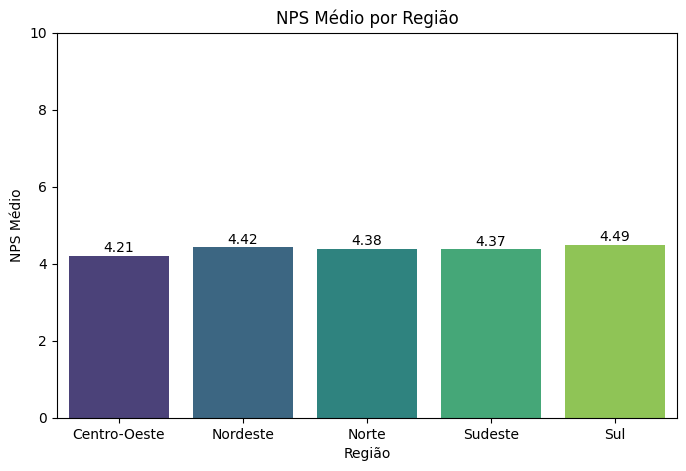

In [49]:
#calculando o NPS médio por região 
nps_por_regiao = df.groupby('customer_region')['nps_score'].mean().reset_index()
# Criando um gráfico de barras para visualizar o NPS médio por região
plt.figure(figsize=(8,5))
sns.barplot(x='customer_region', y='nps_score', data=nps_por_regiao, palette='viridis')
plt.title('NPS Médio por Região')
plt.xlabel('Região')
plt.ylabel('NPS Médio')
plt.ylim(0,10)
# incluindo os rótulos de valor em cada barra
for index, row in nps_por_regiao.iterrows():
    plt.text(index, row['nps_score'] + 0.1, f"{row['nps_score']:.2f}", ha='center')
plt.show()



In [ ]:
# Verificando o formato dos dados
df.shape

(2500, 19)

In [7]:
# Analisando os tipos de dados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

In [9]:
# Verificando a presença de valores nulos
df.isna().sum()

customer_id                  0
customer_age                 0
customer_region              0
customer_tenure_months       0
order_id                     0
order_value                  0
items_quantity               0
discount_value               0
payment_installments         0
delivery_time_days           0
delivery_delay_days          0
freight_value                0
delivery_attempts            0
customer_service_contacts    0
resolution_time_days         0
nps_score                    0
repeat_purchase_30d          0
complaints_count             0
csat_internal_score          0
dtype: int64

## 2. Definição da variável target

A variável-alvo é `nps_score`, pois representa diretamente a nota de satisfação do cliente. Para o modelo de regrassão, ela será tratada como contínua, caracterizando um problema de regressão. Para leitura executiva, também serão criadas categorias: detrator, neutro e promotor.

In [51]:
#Criando uma função para classificar os clientes em detratores, neutros e promotores com base na pontuação NPS
def nps_class(score):
    if score <= 6:
        return 'Detrator'
    if score <= 8:
        return 'Neutro'
    return 'Promotor'
# Aplicando a função para criar a coluna de classificação NPS
df['nps_class'] = df['nps_score'].apply(nps_class)
# Analisando a distribuição das classes NPS
print(df['nps_class'].value_counts(normalize=True))

nps_class
Detrator    0.7404
Neutro      0.1792
Promotor    0.0804
Name: proportion, dtype: float64


C:\Users\augus\AppData\Local\Temp\ipykernel_20380\16604637.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='nps_class', data=df, palette='viridis')


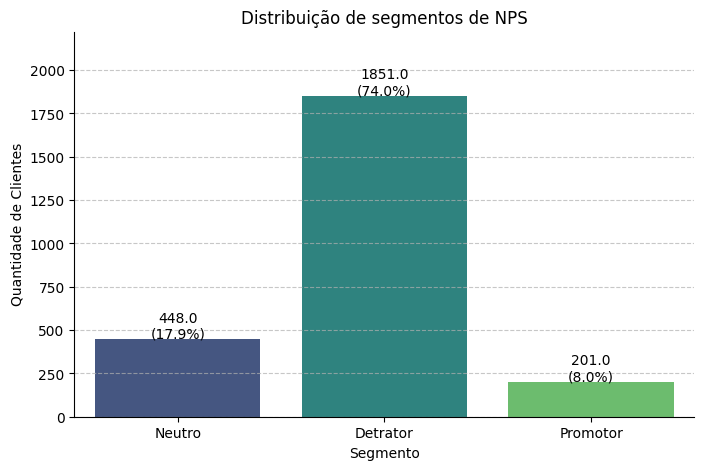

In [57]:
#Plotando a distribuição das classes NPS, quero que coloque a quantidade de clientes e a proporção de cada classe (Segmento) e faça um design bonito do gráfico
plt.figure(figsize=(8,5))
sns.countplot(x='nps_class', data=df, palette='viridis')
plt.title('Distribuição de segmentos de NPS')
plt.xlabel('Segmento')
plt.ylabel('Quantidade de Clientes')
# Adicionando os rótulos de quantidade e proporção em cada barra
total = len(df)
for p in plt.gca().patches:
    height = p.get_height()
    proportion = height / total * 100
    plt.text(p.get_x() + p.get_width() / 2, height + 5, f'{height}\n({proportion:.1f}%)', ha='center')
plt.ylim(0, df['nps_class'].value_counts().max() * 1.2)
# ajustando a área do gráfico adicionando cor e grades para melhorar a visualização
plt.grid(axis='y', linestyle='--', alpha=0.7)
sns.despine()
plt.show()




## 3. EDA — principais fatores críticos

In [15]:
#imprimindo as colunas do dataset
print(df.columns)

Index(['customer_id', 'customer_age', 'customer_region',
       'customer_tenure_months', 'order_id', 'order_value', 'items_quantity',
       'discount_value', 'payment_installments', 'delivery_time_days',
       'delivery_delay_days', 'freight_value', 'delivery_attempts',
       'customer_service_contacts', 'resolution_time_days', 'nps_score',
       'repeat_purchase_30d', 'complaints_count', 'csat_internal_score',
       'nps_class'],
      dtype='object')


In [ ]:
# Analisando a correlação entre as variáveis numéricas e a variável target `nps_score`
corr = df.select_dtypes(include='number').drop(columns=['customer_id','order_id']).corr()['nps_score'].drop('nps_score').sort_values() #Essa linha seleciona apenas as colunas numéricas, remove as colunas de identificação, calcula a correlação com a variável target e ordena os resultados.
corr

delivery_delay_days         -0.597260
complaints_count            -0.496800
customer_service_contacts   -0.350845
resolution_time_days        -0.191392
freight_value               -0.041087
customer_age                -0.009936
customer_tenure_months      -0.009711
delivery_time_days           0.000925
items_quantity               0.011468
payment_installments         0.023718
discount_value               0.025104
delivery_attempts            0.027680
order_value                  0.036990
csat_internal_score          0.563952
repeat_purchase_30d          0.570324
Name: nps_score, dtype: float64

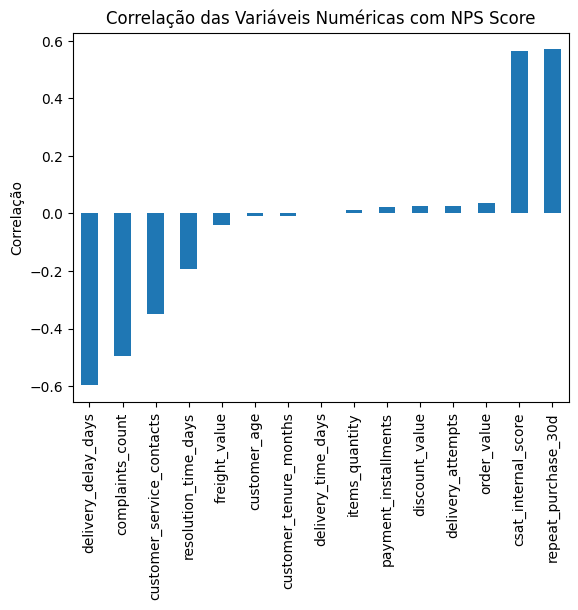

In [19]:
# Visualizando a correlação com um gráfico de barras
corr.plot(kind='bar', title='Correlação das Variáveis Numéricas com NPS Score')
plt.ylabel('Correlação')
plt.show()

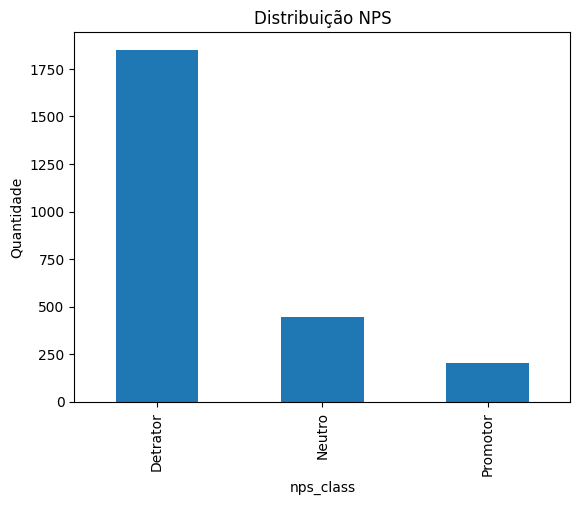

In [20]:
#Visualizando a distribuição de cada classe NPS
ax = df['nps_class'].value_counts().reindex(['Detrator','Neutro','Promotor']).plot(kind='bar', title='Distribuição NPS')
ax.set_ylabel('Quantidade')
plt.show()

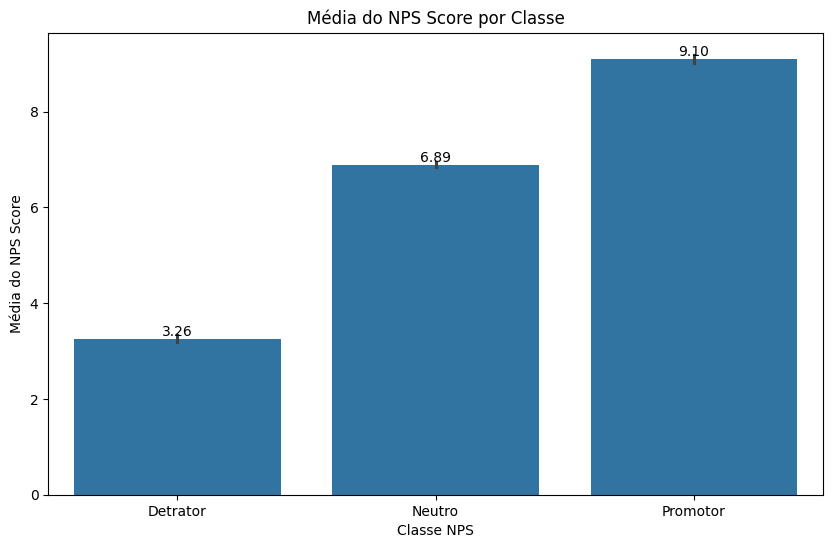

In [25]:
#plotando as médias por classe NPS e inserindo os rótulos de cada barra
plt.figure(figsize=(10,6))
sns.barplot(x='nps_class', y='nps_score', data=df, order=['Detrator','Neutro','Promotor'])
plt.title('Média do NPS Score por Classe')
plt.xlabel('Classe NPS')
plt.ylabel('Média do NPS Score')
# Adicionando os rótulos de cada barra
for index, value in enumerate(df.groupby('nps_class')['nps_score'].mean().reindex(['Detrator','Neutro','Promotor'])):
    plt.text(index, value, f'{value:.2f}', ha='center', va='bottom')
plt.show()


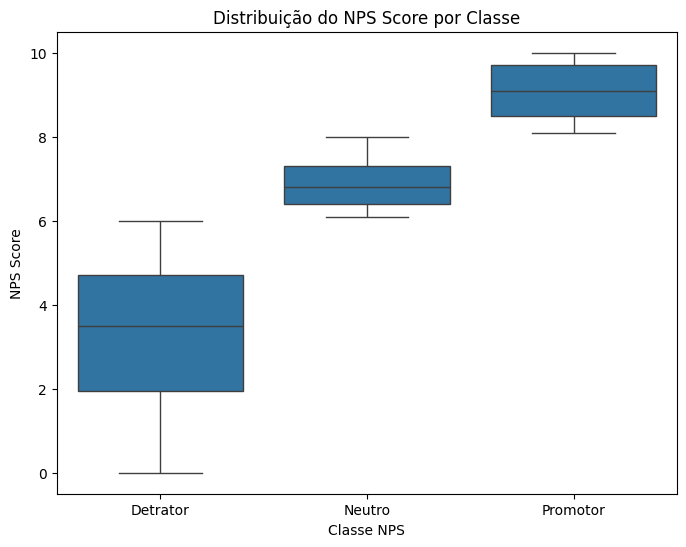

In [23]:
#boxplot para analisar a distribuição do NPS Score por classe
plt.figure(figsize=(8,6))
sns.boxplot(x='nps_class', y='nps_score', data=df, order=['Detrator','Neutro','Promotor'])
plt.title('Distribuição do NPS Score por Classe')
plt.xlabel('Classe NPS')
plt.ylabel('NPS Score')
plt.show()


In [30]:
# Analisando a relação entre o atraso na entrega e a pontuação NPS
delay = df.groupby('delivery_delay_days')['nps_score'].agg(['count','mean']).reset_index()
delay

,delivery_delay_days,count,mean
0,0,277,6.856679
1,1,615,5.546179
2,2,646,4.580186
3,3,525,3.436762
4,4,270,2.444444
5,5,116,1.481034
6,6,34,1.097059
7,7,14,0.292857
8,8,3,0.000000


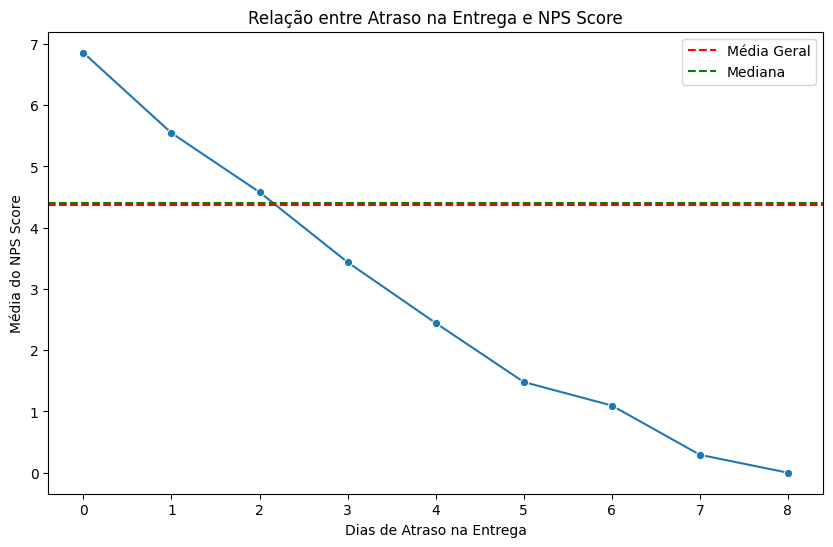

In [34]:
# Visualizando a relação entre o atraso na entrega e a pontuação NPS: uma linha pontilhada na média geral e outra linha na mediana do NPS Score e mostrando a queda da nota (NPS Score) à medida que o atraso aumenta.
plt.figure(figsize=(10,6))
sns.lineplot(x='delivery_delay_days', y='mean', data=delay, marker='o')     
plt.axhline(df['nps_score'].mean(), color='red', linestyle='--', label='Média Geral')  # Linha pontilhada para a média geral
plt.axhline(df['nps_score'].median(), color='green', linestyle='--', label='Mediana')  # Linha pontilhada para a mediana
plt.title('Relação entre Atraso na Entrega e NPS Score')
plt.xlabel('Dias de Atraso na Entrega')
plt.ylabel('Média do NPS Score')
plt.legend()
plt.show()

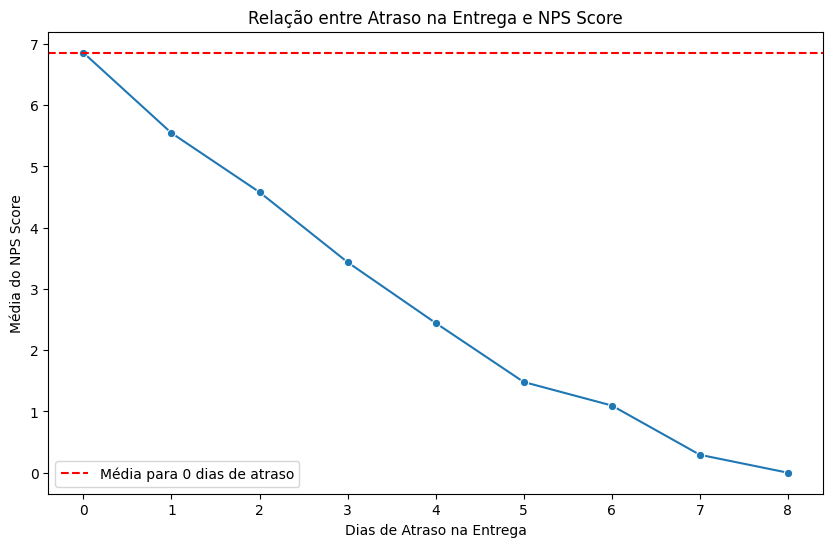

In [35]:
# Visualizando a relação entre o atraso na entrega e a pontuação NPS: uma linha pontilhada na média do NPS Score para zero atraso e mostrando a queda da nota (NPS Score) à medida que o atraso aumenta.
plt.figure(figsize=(10,6))
sns.lineplot(x='delivery_delay_days', y='mean', data=delay, marker='o')
plt.axhline(delay[delay['delivery_delay_days'] == 0]['mean'].values[0], color='red', linestyle='--', label='Média para 0 dias de atraso')  # Linha pontilhada para a média do NPS Score para zero atraso
plt.title('Relação entre Atraso na Entrega e NPS Score')
plt.xlabel('Dias de Atraso na Entrega')
plt.ylabel('Média do NPS Score')
plt.legend()
plt.show()

**Leitura executiva:** o atraso na entrega é o principal fator negativo. O ponto de ruptura aparece já a partir de 1 dia de atraso, com queda perceptível no NPS médio.

## 4. Modelagem de regressão

In [ ]:
# Separando as variáveis de entrada (X) e a variável target (y) para a modelagem preditiva do NPS Score
features = [c for c in df.columns if c not in ['nps_score','nps_class','customer_id','order_id']] #Essa linha cria uma lista de features, excluindo as colunas de identificação e a variável target.
X = df[features]
y = df['nps_score']
cat_cols = X.select_dtypes(include='object').columns.tolist() #Essa linha identifica as colunas categóricas, selecionando as colunas do DataFrame X que possuem o tipo de dado 'object' e armazenando seus nomes em uma lista chamada cat_cols.
num_cols = [c for c in X.columns if c not in cat_cols] #Essa linha cria uma lista de colunas numéricas, selecionando as colunas do DataFrame X que não estão na lista de colunas categóricas (cat_cols) e armazenando seus nomes em uma lista chamada num_cols.
preprocessor = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols), ('num', StandardScaler(), num_cols)]) #
#Separando os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#Criando uma função para avaliar os modelos utilizando as métricas MAE, RMSE e R2, onde a função recebe os valores reais (y_true) e as previsões do modelo (y
def evaluate(y_true, y_pred):
    return {'MAE': mean_absolute_error(y_true,y_pred), 'RMSE': mean_squared_error(y_true,y_pred)**0.5, 'R2': r2_score(y_true,y_pred)}

models = {
    'Ridge Regression': Pipeline([('preprocess', preprocessor), ('model', Ridge(alpha=1.0))]),
    'Random Forest Regressor': Pipeline([('preprocess', preprocessor), ('model', RandomForestRegressor(n_estimators=250, min_samples_leaf=5, random_state=42, n_jobs=-1))]),
    'Gradient Boosting Regressor': Pipeline([('preprocess', preprocessor), ('model', GradientBoostingRegressor(random_state=42))])
}
rows=[]
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = np.clip(model.predict(X_test), 0, 10)
    rows.append({'modelo': name, **evaluate(y_test,pred)})
metrics = pd.DataFrame(rows).sort_values('MAE')
metrics

,modelo,MAE,RMSE,R2
0,Ridge Regression,1.186914,1.493398,0.647042
2,Gradient Boosting Regressor,1.221452,1.523298,0.632767
1,Random Forest Regressor,1.247111,1.557809,0.615939


## 5. Regressão quantílica

A regressão quantílica permite estimar faixas prováveis de NPS, não apenas uma média. Isso é útil para priorizar clientes com maior risco ou maior incerteza.

In [40]:
#Regressão Quantílica para estimar os intervalos de confiança das previsões, onde os quantis q10 e q90 representam os limites inferior e superior do intervalo de confiança, respectivamente, e o quantil q50 representa a mediana prevista.
quantile_models = {}
for q in [0.10, 0.50, 0.90]:
    q_model = Pipeline([('preprocess', preprocessor), ('model', GradientBoostingRegressor(loss='quantile', alpha=q, random_state=42))])
    q_model.fit(X_train, y_train)
    quantile_models[q] = q_model
# Quantis avaliados para calcular a cobertura do intervalo de confiança, onde a cobertura representa a proporção de casos em que o valor real (y_test) está dentro do intervalo definido pelos quantis q10 e q90.
pred_q10 = np.clip(quantile_models[0.10].predict(X_test),0,10)
pred_q50 = np.clip(quantile_models[0.50].predict(X_test),0,10)
pred_q90 = np.clip(quantile_models[0.90].predict(X_test),0,10)
coverage = ((y_test >= pred_q10) & (y_test <= pred_q90)).mean()
{'MAE_q50': mean_absolute_error(y_test,pred_q50), 'RMSE_q50': mean_squared_error(y_test,pred_q50)**0.5, 'R2_q50': r2_score(y_test,pred_q50), 'coverage_80pct': coverage}

{'MAE_q50': 1.236219301594579,
 'RMSE_q50': 1.5432968384462415,
 'R2_q50': 0.6230615593515808,
 'coverage_80pct': np.float64(0.738)}

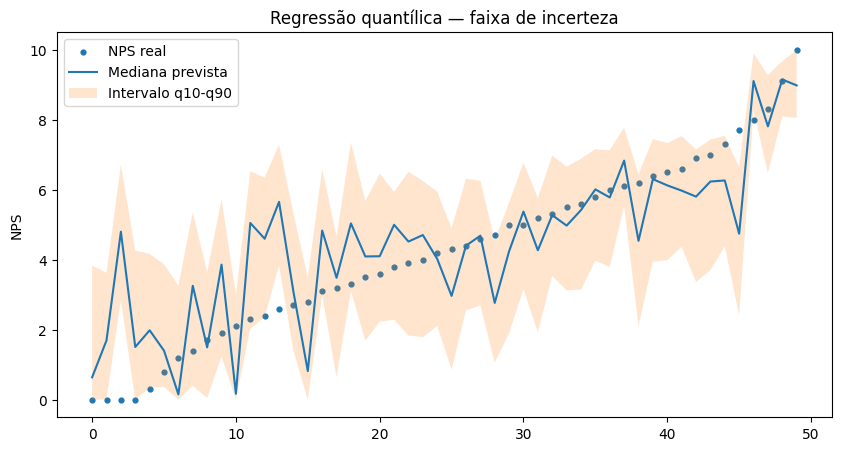

In [ ]:
#plotando os resultados da regressão quantílica para visualizar a faixa de incerteza das previsões, onde a linha pontilhada representa a mediana prevista (q50) e a área sombreada representa o intervalo entre os quantis q10 e q90.
plot_df = pd.DataFrame({'real': y_test.values, 'q10': pred_q10, 'q50': pred_q50, 'q90': pred_q90}).sort_values('real').reset_index(drop=True).iloc[::10]
x = np.arange(len(plot_df))
plt.figure(figsize=(10,5))
plt.scatter(x, plot_df['real'], s=12, label='NPS real')
plt.plot(x, plot_df['q50'], label='Mediana prevista')
plt.fill_between(x, plot_df['q10'], plot_df['q90'], alpha=0.2, label='Intervalo q10-q90')
plt.legend()
plt.title('Regressão quantílica — faixa de incerteza')
plt.ylabel('NPS')
plt.show()

## 6. Recomendações práticas

1. Criar alertas preventivos para pedidos com atraso maior ou igual a 1 dia.
2. Priorizar atendimento proativo para clientes com múltiplas reclamações ou contatos.
3. Usar o modelo para gerar uma fila diária de clientes em risco de detrator.
4. Usar regressão quantílica para diferenciar clientes com previsão baixa e alta incerteza.
5. Medir o impacto das ações por experimento A/B ou análise antes/depois.